In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_curve, auc, 
                             classification_report, roc_auc_score, precision_score, 
                             recall_score, f1_score, matthews_corrcoef, 
                             cohen_kappa_score, balanced_accuracy_score, ConfusionMatrixDisplay)

In [2]:

df_il = pd.read_excel("il_verileri.xlsx")


def clean_total_rows(df, col_name):
    if col_name in df.columns:
        return df[df[col_name].astype(str).str.contains('Toplam') == False]
    return df

if not df_il.empty:
    df_il = clean_total_rows(df_il, 'il')
    
    
    df_il['Olum_Orani'] = df_il['il_toplam_olu'] / df_il['illere_gore_toplam_kaza_sayisi']
    limit = df_il['Olum_Orani'].median()
    df_il['Risk_Status'] = df_il['Olum_Orani'].apply(lambda x: 1 if x > limit else 0)

    
    features = ['illere_gore_toplam_kaza_sayisi', 
                'illere_gore_maddi_hasarli_kaza_sayisi', 
                'illere_gore_yarali_sayisi']
    
    print("Veri yüklendi ve temizlendi.")

Veri yüklendi ve temizlendi.



--- Summary Statistics ---
                                       count          mean           std  \
illere_gore_toplam_kaza_sayisi         486.0  15081.119342  38262.041846   
illere_gore_maddi_hasarli_kaza_sayisi  486.0   2494.485597   3485.775141   
illere_gore_yarali_sayisi              486.0   3721.775720   4596.344950   
Risk_Status                            486.0      0.500000      0.500515   

                                         min      25%     50%       75%  \
illere_gore_toplam_kaza_sayisi         444.0  2643.50  4874.5  12670.75   
illere_gore_maddi_hasarli_kaza_sayisi  129.0   732.25  1265.5   2824.50   
illere_gore_yarali_sayisi              238.0  1229.50  2103.5   4496.00   
Risk_Status                              0.0     0.00     0.5      1.00   

                                            max  
illere_gore_toplam_kaza_sayisi         351729.0  
illere_gore_maddi_hasarli_kaza_sayisi   33636.0  
illere_gore_yarali_sayisi               41414.0  
Risk_Status    

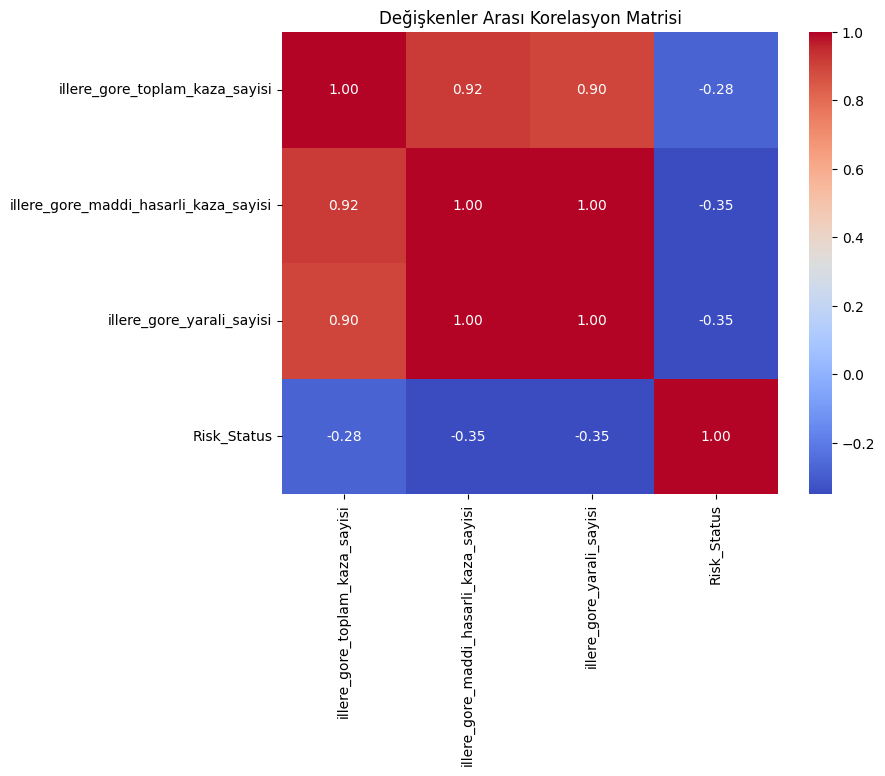

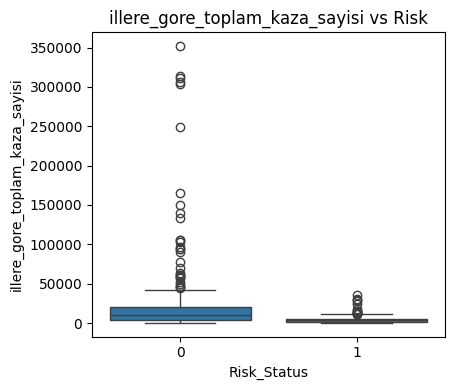

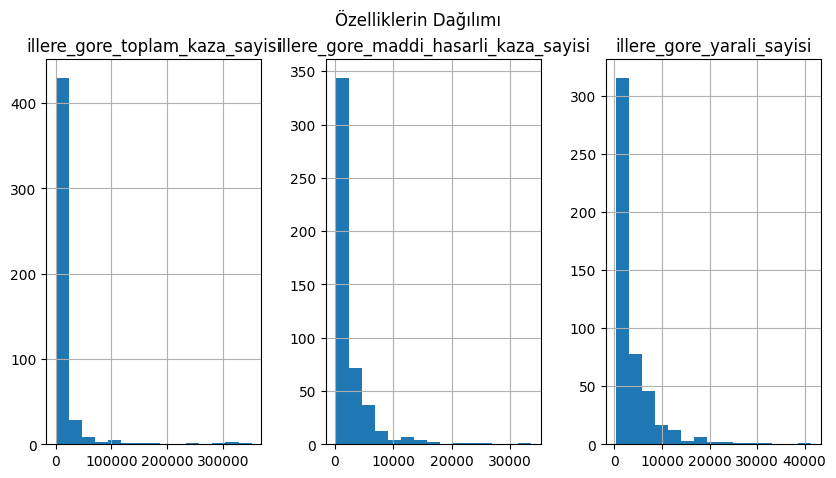

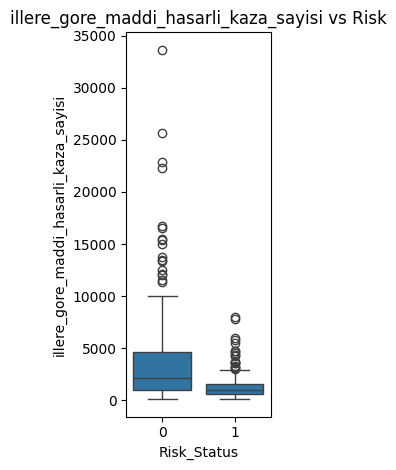

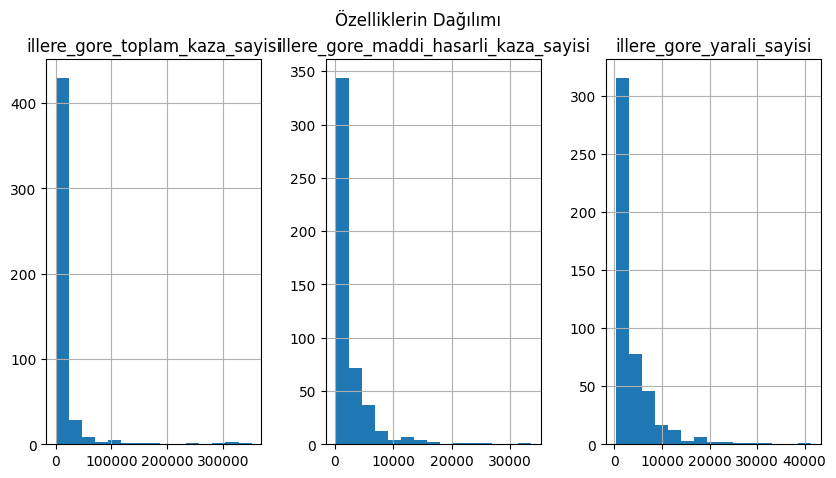

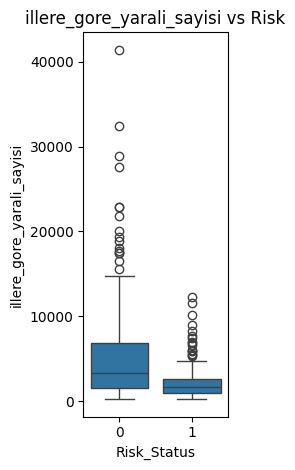

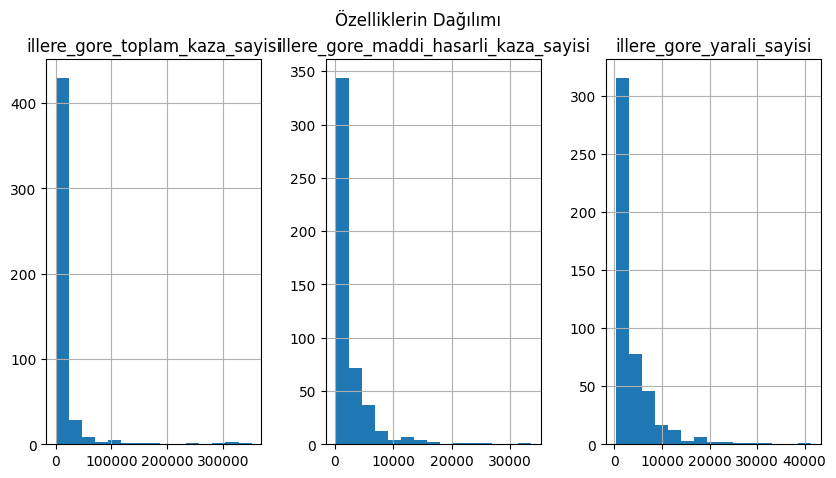

In [3]:
print("\n--- Summary Statistics ---")
print(df_il[features + ['Risk_Status']].describe().T)


plt.figure(figsize=(8, 6))
sns.heatmap(df_il[features + ['Risk_Status']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Değişkenler Arası Korelasyon Matrisi")
plt.show()


plt.figure(figsize=(12, 4))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='Risk_Status', y=col, data=df_il)
    plt.title(f"{col} vs Risk")
    plt.tight_layout()
    plt.show()

    
    df_il[features].hist(bins=15, figsize=(10, 5), layout=(1, 3))
    plt.suptitle("Özelliklerin Dağılımı ")
    plt.show()



--- Hyperparameter Tuning  ---
En iyi Decision Tree Parametreleri: {'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 2}
En iyi Grid Skoru: 0.7588

Modeller eğitiliyor...


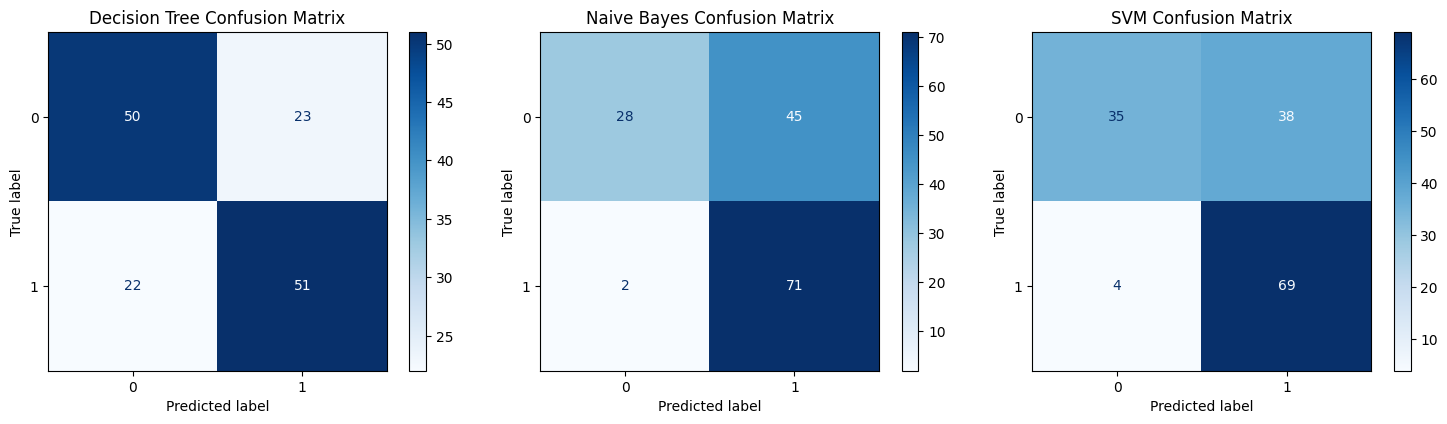

In [4]:
X = df_il[features]
y = df_il['Risk_Status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


print("\n--- Hyperparameter Tuning  ---")
param_grid = {
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
    }
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
    
best_dt_params = grid_search.best_params_
print(f"En iyi Decision Tree Parametreleri: {best_dt_params}")
print(f"En iyi Grid Skoru: {grid_search.best_score_:.4f}")


models = {
    "Decision Tree": DecisionTreeClassifier(**best_dt_params, random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42)
    }

roc_data = {}
learning_curve_data = {}
model_comparison = []

print("\nModeller eğitiliyor...")


fig_cm, axes_cm = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, model) in enumerate(models.items()):
        
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    
        
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
        
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
        
    
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0 
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
        
    try:
        auc_val = roc_auc_score(y_test, y_proba)
    except:
        auc_val = 0.5

    
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    mean_cv_score = cv_scores.mean()

    model_comparison.append({
        'Model': name,
        'Accuracy': acc,
        'Balanced Acc': balanced_acc,
        'Specificity': specificity,
        'MCC': mcc,
        'Kappa': kappa,
        'F1-score': f1,
        'ROC-AUC': auc_val,
        'CV Mean Score': mean_cv_score
        })

    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc_val)
        
    
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5)
        )
    learning_curve_data[name] = (train_sizes, np.mean(train_scores, axis=1), np.mean(test_scores, axis=1))

    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=axes_cm[i], cmap='Blues')
    axes_cm[i].set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()


FINAL MODEL COMPARISON TABLE
        Model  Accuracy  Balanced Acc  Specificity   MCC  Kappa  F1-score  ROC-AUC  CV Mean Score
Decision Tree     0.692         0.692        0.685 0.384  0.384     0.692    0.652          0.759
  Naive Bayes     0.678         0.678        0.384 0.441  0.356     0.648    0.719          0.679
          SVM     0.712         0.712        0.479 0.480  0.425     0.696    0.747          0.697


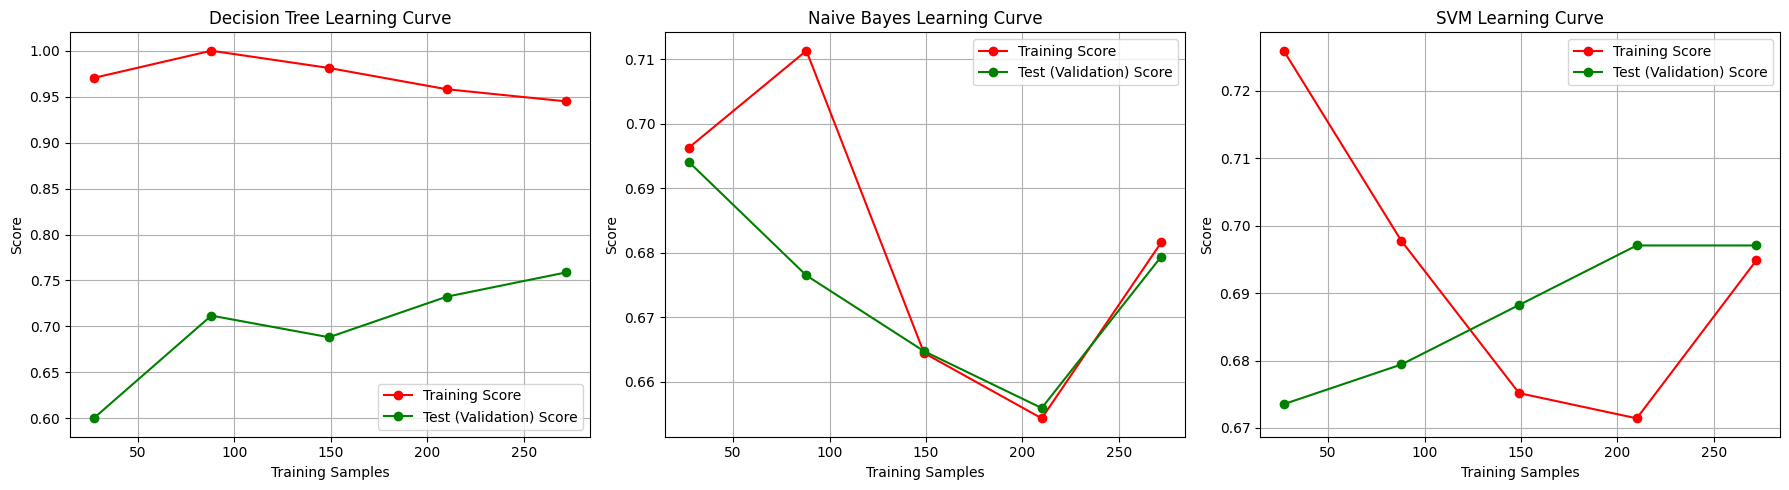

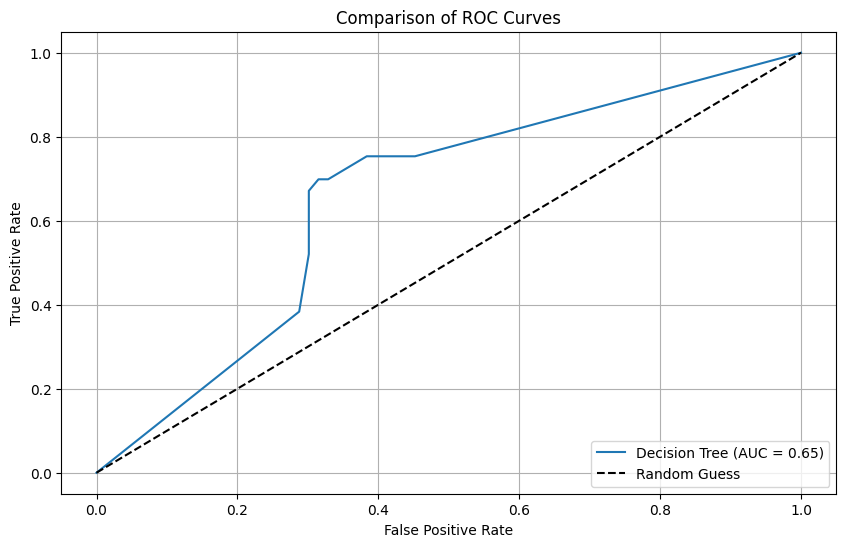

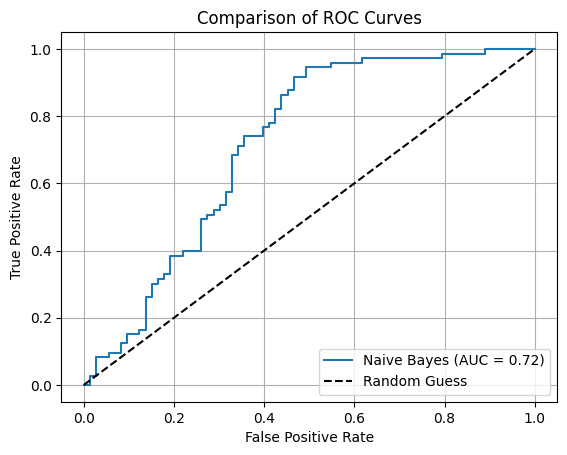

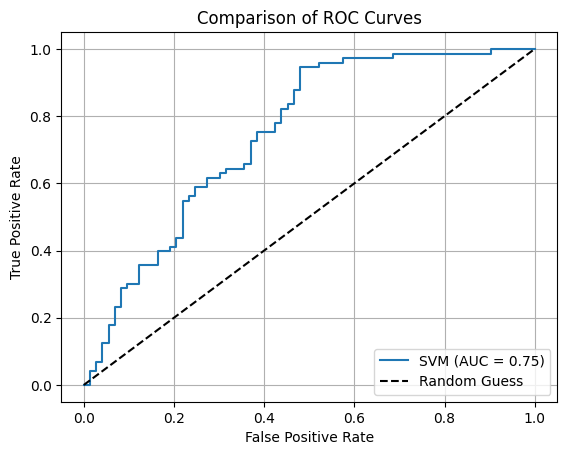


 >>> BEST MODEL: SVM (Accuracy: %71.20)


In [5]:
comparison_table = pd.DataFrame(model_comparison)
comparison_table = comparison_table.round(3)
    
print("\nFINAL MODEL COMPARISON TABLE")
print(comparison_table.to_string(index=False)) 


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, data) in enumerate(learning_curve_data.items()):
    train_sizes, train_mean, test_mean = data
    axes[i].plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
    axes[i].plot(train_sizes, test_mean, 'o-', color="g", label="Test (Validation) Score")
    axes[i].set_title(f"{name} Learning Curve")
    axes[i].set_xlabel("Training Samples")
    axes[i].set_ylabel("Score")
    axes[i].legend(loc="best")
    axes[i].grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
for name, (fpr, tpr, auc_val) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Comparison of ROC Curves')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

best_row = comparison_table.loc[comparison_table['Accuracy'].idxmax()]
print(f"\n >>> BEST MODEL: {best_row['Model']} (Accuracy: %{best_row['Accuracy']*100:.2f})")